Project Title :AI vs Human Text Detection Using Machine Learning

PART 1: PROJECT FRAMING (WITH CODE)

In [ ]:
print("Domain        : Education / Natural Language Processing (NLP)")
print("Problem Type  : Classification")
print("Objective     : Identify whether a text is AI-generated or Human-written")

Domain        : Education / Natural Language Processing (NLP)
Problem Type  : Classification
Objective     : Identify whether a text is AI-generated or Human-written


Problem Statement:
With the increasing use of AI tools, it has become difficult to identify whether student assignments, projects, or handwritten-to-digital content are created by humans or generated using AI.
This project aims to build a machine learning model that classifies text as AI-generated or Human-written.

Create  Dataset (CODE)

In [ ]:
uploaded = files.upload()
for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving ai detection.csv to ai detection (2).csv
User uploaded file "ai detection (2).csv" with length 1620540 bytes


In [ ]:
import pandas as pd
from google.colab import files

# The file 'ai detection (1).csv' was uploaded directly.
df = pd.read_csv("ai detection (1).csv")
df.head()

,id,text,human_or_ai,source_model,prompt,domain,language,edit_level,word_count,generation_date,version
0,e37e31c0-35d0-486d-9760-efadd4e0e289,Aprender programación en Python es fácil . Pri...,human,Human,NaN,Technical Blog,es,none,34,2026-01-29T08:38:18.272755,v1.0
1,68e294cf-a499-4fbf-8616-2d6324570be9,Error: 400 Client Error: Bad Request for url: ...,ai,gemma2-9b-it,Discute el papel de la tecnología en el aprend...,Education,es,none,9,2026-01-29T08:58:20.717225,v1.0
2,b5e06ef0-9758-471f-81dc-182c6117ee81,Error: 404 Client Error: Not Found for url: ht...,ai,gemma2-9b-itllama-3.3-70b-versatile,Create a cold outreach email for business part...,Email,en,none,9,2026-01-29T09:13:20.114765,v1.0
3,6177fc40-1567-445b-af15-f3250ddd3403,**Global Economic Trends: A Shifting Landscape...,ai,llama-3.1-8b-instant,Write about economic trends affecting global m...,News,en,none,558,2026-01-29T08:39:55.917663,v1.0
4,192a9615-ed51-4750-b649-d18f8882f555,"""Recuerda que tú eres fuerte, capaz y única. N...",ai,llama-3.1-8b-instant,Escribe una publicación inspiradora para redes...,Social Media,es,none,147,2026-01-29T08:42:52.451370,v1.0


PART 3: DATA UNDERSTANDING

In [ ]:
df.info()
df['human_or_ai'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               686 non-null    object
 1   text             686 non-null    object
 2   human_or_ai      686 non-null    object
 3   source_model     686 non-null    object
 4   prompt           505 non-null    object
 5   domain           686 non-null    object
 6   language         686 non-null    object
 7   edit_level       686 non-null    object
 8   word_count       686 non-null    int64 
 9   generation_date  686 non-null    object
 10  version          686 non-null    object
dtypes: int64(1), object(10)
memory usage: 59.1+ KB


,count
human_or_ai,
ai,335
human,181
post_edited_ai,170


PART 4: DATA CLEANING & PREPROCESSING

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

PART 5: FEATURE EXTRACTION (TEXT → NUMBERS)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['human_or_ai']

PART 6: TRAIN–TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

PART 7: MODEL BUILDING

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

PART 8: MODEL EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7318840579710145
                precision    recall  f1-score   support

            ai       0.66      0.97      0.79        71
         human       0.96      0.68      0.79        40
post_edited_ai       0.83      0.19      0.30        27

      accuracy                           0.73       138
     macro avg       0.82      0.61      0.63       138
  weighted avg       0.78      0.73      0.70       138



PART 9: TEST WITH NEW TEXT

In [ ]:
def predict_text(input_text):
    clean = clean_text(input_text)
    vector = vectorizer.transform([clean])
    prediction = model.predict(vector)
    return "AI Generated" if prediction[0] == 1 else "Human Written"

predict_text("I personally worked on this project and learned new concepts")

'Human Written'

VISUAL EVALUATION

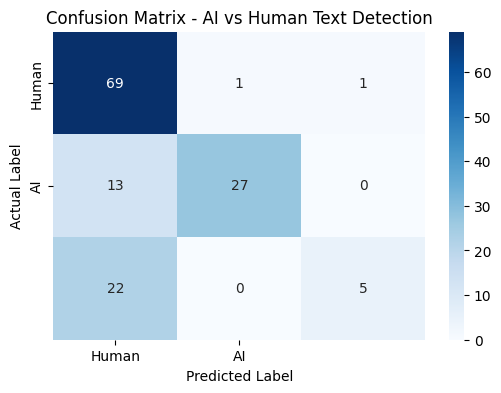

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - AI vs Human Text Detection")
plt.show()

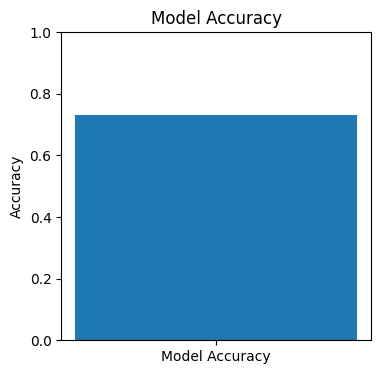

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.bar(['Model Accuracy'], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

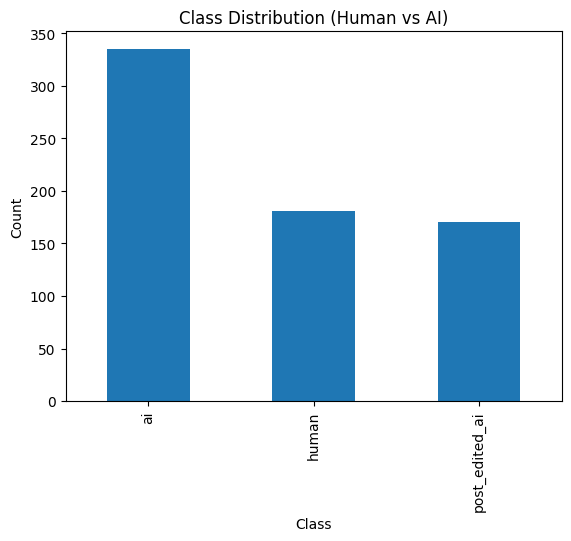

In [ ]:
df['human_or_ai'].value_counts().plot(
    kind='bar',
    title='Class Distribution (Human vs AI)',
    xlabel='Class',
    ylabel='Count'
)
plt.show()